<a href="https://colab.research.google.com/github/RafaSFernandes/data-cleaning-and-wrangling-airbnb/blob/main/notebooks/data_cleaning_and_wrangling_airbnb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#0. Libraries

In [245]:
# Data
import pandas as pd

# Math
import numpy as np

# Graphics
import matplotlib.pyplot as plt
import seaborn as sns

#1. Data Loading

In [246]:
# Files path
path = "https://raw.githubusercontent.com/RafaSFernandes/data-cleaning-and-wrangling-airbnb/refs/heads/main/data/"

In [247]:
# Reading files
df_listings = pd.read_csv(path + "listings_cleaned.csv")
df_reviews = pd.read_csv(path + "reviews.csv")

In [248]:
# Showing first rows
df_listings.head()

,id,neighbourhood_cleansed,room_type,accommodates,bathrooms,bedrooms,beds,price
0,271975,Vidigal,Entire home/apt,4,1.0,2.0,2.0,236.0
1,272335,Copacabana,Entire home/apt,4,1.0,1.0,1.0,723.0
2,272631,Copacabana,Private room,2,1.0,1.0,2.0,1146.0
3,273261,Leblon,Entire home/apt,6,3.5,3.0,3.0,6742.0
4,273363,Santa Teresa,Private room,1,1.0,1.0,1.0,61.0


In [249]:
# Showing first rows
df_reviews.head()

,id,number_of_reviews,review_scores_rating
0,272335,367,4.92
1,272631,32,5.00
2,273363,5,5.00
3,273463,654,4.83
4,273496,60,4.80


#2. Data Exploration

## Report

**2.1. df_listings**

Displays accommodation information. It has 8 columns.

* **id** -> accommodation code (unique values)
* **neighbourhood_cleansed** -> neighborhood names already cleaned to avoid duplicates and errors in names
* **room_type** -> accommodation type
* **accommodates** -> guest capacity
* **bathrooms** -> number of bathrooms
* **bedrooms** -> number of bedrooms
* **beds** -> number of beds
* **price** -> daily rate

There are no duplicate values.

It shows some null values ​​that will be handled after merging the data frames.

**2.2. df_reviews**

Displays review information for each accommodation. It contains only 3 columns.

* **id** -> accommodation code (unique values)
* **number_of_reviews** -> number of reviews
* **reviews_score_rating** -> review score

There are no duplicated or null values.

**2.3. Merging Data Frames**

Since we working with reviews of accommodations, the merge method will be left join on id.

This will generate some null values to accommodations with no reviews.



##2.1. df_listings

In [250]:
# Information
df_listings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39499 entries, 0 to 39498
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      39499 non-null  int64  
 1   neighbourhood_cleansed  39499 non-null  object 
 2   room_type               39499 non-null  object 
 3   accommodates            39499 non-null  int64  
 4   bathrooms               36609 non-null  float64
 5   bedrooms                38976 non-null  float64
 6   beds                    36630 non-null  float64
 7   price                   36644 non-null  float64
dtypes: float64(4), int64(2), object(2)
memory usage: 2.4+ MB


In [251]:
# Dimensions
df_listings.shape

(39499, 8)

In [252]:
# Duplicated rows
df_listings.duplicated().any()

np.False_

In [253]:
# Checking the unique values on id column
df_listings.nunique()

,0
id,39499
neighbourhood_cleansed,153
room_type,4
accommodates,16
bathrooms,28
bedrooms,22
beds,40
price,3402


##2.2. df_reviews

In [254]:
# Information
df_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32695 entries, 0 to 32694
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    32695 non-null  int64  
 1   number_of_reviews     32695 non-null  int64  
 2   review_scores_rating  32695 non-null  float64
dtypes: float64(1), int64(2)
memory usage: 766.4 KB


In [255]:
# Dimensions
df_reviews.shape

(32695, 3)

In [256]:
# Duplicated rows
df_reviews.duplicated().any()

np.False_

In [257]:
# Checking the unique values on id column
df_reviews.nunique()

,0
id,32695
number_of_reviews,387
review_scores_rating,137


##2.3. Merging Data Frames

In [258]:
# Left join on id
df_main = pd.merge(df_listings, df_reviews, how='left', on='id')

In [259]:
# Displaying the first rows
df_main.head()

,id,neighbourhood_cleansed,room_type,accommodates,bathrooms,bedrooms,beds,price,number_of_reviews,review_scores_rating
0,271975,Vidigal,Entire home/apt,4,1.0,2.0,2.0,236.0,NaN,NaN
1,272335,Copacabana,Entire home/apt,4,1.0,1.0,1.0,723.0,367.0,4.920000
2,272631,Copacabana,Private room,2,1.0,1.0,2.0,1146.0,32.0,5.000000
3,273261,Leblon,Entire home/apt,6,3.5,3.0,3.0,6742.0,0.0,4.812309
4,273363,Santa Teresa,Private room,1,1.0,1.0,1.0,61.0,5.0,5.000000


In [260]:
# Dimensions
df_main.shape

(39499, 10)

#3. Data Cleaning and Wrangling

##3.1. Null values

### Report

Comparing the removal of null values ​​(`.dropna()`) with the replacement of nulls with the median (`.fillna()`), we see that there are impacts on the database.

Removing the null values significantly impacts the `price` column, approximately 36% in its mean and 86% in its standard deviation.

Replacing the null values with the median impacts:

`number_of_reviews` (13% in the mean and 8% in the standard deviation)

`review_scores_rating` (0.4% in the mean and 9% in the standard deviation)

On the other hand, replacement by mean significantly impacts the Quartlie 2 of the `number of reviews`.

Because it has a smaller impact, the method for handling null values ​​will be the **replacement with the median**.

###3.1.1. Identifying

In [261]:
# Null values percentage by column
(df_main.isnull().sum() / df_main.shape[0] * 100).sort_values(ascending=False)

,0
review_scores_rating,17.225753
number_of_reviews,17.225753
bathrooms,7.316641
beds,7.263475
price,7.228031
bedrooms,1.324084
neighbourhood_cleansed,0.000000
id,0.000000
room_type,0.000000
accommodates,0.000000


###3.1.2. Comparisions

In [262]:
# Null values drop impact on statistics
(
    (abs((df_main.dropna().describe() - df_main.describe()))/df_main.describe()*100)
    .style.format("{:.2f}%")
    .background_gradient(cmap='YlOrRd', axis=1)
)

,id,accommodates,bathrooms,bedrooms,beds,price,number_of_reviews,review_scores_rating
count,17.23%,17.23%,10.69%,16.12%,10.74%,10.78%,0.00%,0.00%
mean,2.27%,6.18%,8.33%,8.27%,7.19%,36.19%,0.00%,0.00%
std,0.42%,14.75%,23.98%,14.64%,15.02%,86.13%,0.00%,0.00%
min,0.00%,0.00%,nan%,nan%,nan%,0.00%,nan%,nan%
25%,2.99%,0.00%,0.00%,0.00%,0.00%,3.50%,0.00%,0.00%
50%,3.26%,0.00%,0.00%,0.00%,0.00%,7.83%,0.00%,0.00%
75%,0.62%,20.00%,0.00%,0.00%,0.00%,13.67%,0.00%,0.00%
max,0.00%,0.00%,0.00%,13.33%,10.71%,98.00%,0.00%,0.00%


In [263]:
# Numeric columns select
df_main_num = df_main.select_dtypes(include='number')

In [264]:
# Null values replacement by median impact on statistics
(
    (abs((df_main.fillna(df_main_num.median()).describe() - df_main.describe()))/df_main.describe()*100)
    .style.format("{:.2f}%")
    .background_gradient(cmap='YlOrRd', axis=1)
)

,id,accommodates,bathrooms,bedrooms,beds,price,number_of_reviews,review_scores_rating
count,0.00%,0.00%,7.89%,1.34%,7.83%,7.79%,20.81%,20.81%
mean,0.00%,0.00%,2.49%,0.47%,1.12%,2.94%,12.94%,0.05%
std,0.00%,0.00%,2.73%,0.48%,3.58%,3.62%,7.83%,9.00%
min,0.00%,0.00%,nan%,nan%,nan%,0.00%,nan%,nan%
25%,0.00%,0.00%,0.00%,0.00%,0.00%,7.25%,0.00%,0.00%
50%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%
75%,0.00%,0.00%,0.00%,0.00%,0.00%,3.08%,23.08%,0.60%
max,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%


In [265]:
# Null values replacement by mean impact on statistics
(
    (abs((df_main.fillna(df_main_num.mean()).describe() - df_main.describe()))/df_main.describe()*100)
    .style.format("{:.2f}%")
    .background_gradient(cmap='YlOrRd', axis=1)
)

,id,accommodates,bathrooms,bedrooms,beds,price,number_of_reviews,review_scores_rating
count,0.00%,0.00%,7.89%,1.34%,7.83%,7.79%,20.81%,20.81%
mean,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%
std,0.00%,0.00%,3.73%,0.66%,3.70%,3.68%,9.02%,9.02%
min,0.00%,0.00%,nan%,nan%,nan%,0.00%,nan%,nan%
25%,0.00%,0.00%,0.00%,0.00%,0.00%,7.25%,0.00%,0.00%
50%,0.00%,0.00%,0.00%,0.00%,0.00%,8.65%,83.33%,0.29%
75%,0.00%,0.00%,0.00%,0.00%,0.00%,2.26%,7.18%,0.60%
max,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%


###3.1.3. Replacement

In [266]:
# Replacement by median
df_main = df_main.fillna(df_main_num.median())

##3.2. Inconsistences

### Report

**3.2.1. Not integer values**

Presence of variables that must be integers in the columns `bathrooms`, `bedrooms`, `beds`, and `number_of_reviews`.

The `bathrooms` column is the only one that presents inconsistency, as some values ​​are not integers.

An accomomodation with 1.5 bathrooms doesn't make sense, right?

10% of inconsistent values ​​in the `bathroom` column.

The not integer values will be replaced by the truncated value.

**3.2.2. Duplicates**

There are no duplicated values.

###3.2.1. Not integer values

In [267]:
# Checking data types
df_main.dtypes

,0
id,int64
neighbourhood_cleansed,object
room_type,object
accommodates,int64
bathrooms,float64
bedrooms,float64
beds,float64
price,float64
number_of_reviews,float64
review_scores_rating,float64


In [268]:
# Integer values columns
cols_int = ['bathrooms', 'bedrooms', 'beds', 'number_of_reviews']

In [269]:
# Not integer values in columns
((df_main[cols_int] - df_main[cols_int].astype(int)) != 0).any()

,0
bathrooms,True
bedrooms,False
beds,False
number_of_reviews,False


In [270]:
# Checking inconsistent values proportion
(
    ((df_main[cols_int[0]] - df_main[cols_int[0]].astype(int)) != 0).value_counts(normalize=True)
)

,proportion
bathrooms,
False,0.897947
True,0.102053


In [271]:
# Transforming integer columns
df_main[cols_int] = df_main[cols_int].astype(int)

In [272]:
# Checking not integer values presence
((df_main[cols_int] - df_main[cols_int].astype(int)) != 0).any()

,0
bathrooms,False
bedrooms,False
beds,False
number_of_reviews,False


### 3.2.2. Duplicated values

In [273]:
# Checking duplicates
df_main.duplicated().any()

np.False_

##3.3. Data Types

### Report

The only data type left to change is `id` column dtype.

Usually we use strings to these kinds of data, as `id` works as an identifier, not a quantifier.

### 3.3.1. Checking and updating

In [274]:
# Checking Data Types
df_main.dtypes

,0
id,int64
neighbourhood_cleansed,object
room_type,object
accommodates,int64
bathrooms,int64
bedrooms,int64
beds,int64
price,float64
number_of_reviews,int64
review_scores_rating,float64


In [275]:
# Updating
df_main['id'] = df_main['id'].astype(str)

##3.4. Outliers

### Report

**3.4.2. Statistics**

The accommodations listed as having 20 bathrooms, 30 bedrooms, or 56 beds are strikingly improbable, likely indicating errors.

The daily rental price of 500,000 may be real, but it is far out of the ordinary compared to the overall data.

Notably, the outliers in the price column stand out from the other columns. This will be the main focus of the analysis.

###3.4.1. Numeric and Categoric Split

In [276]:
# Spliting columns names in separated lists
num_cols = ['accommodates', 'bathrooms', 'bedrooms', 'beds', 'price', 'number_of_reviews','review_scores_rating']
cat_cols = ['neighbourhood_cleansed', 'room_type']

###3.4.2. Statistics

In [277]:
# Statistics
df_main.describe()

,accommodates,bathrooms,bedrooms,beds,price,number_of_reviews,review_scores_rating
count,39499.000000,39499.000000,39499.000000,39499.000000,39499.000000,39499.000000,39499.000000
mean,4.002608,1.427935,1.537836,2.338464,1191.045039,21.008709,4.818532
std,2.294602,0.914154,1.015503,1.907210,3630.553054,42.757580,0.269711
min,1.000000,0.000000,0.000000,0.000000,33.000000,0.000000,0.000000
25%,2.000000,1.000000,1.000000,1.000000,429.000000,1.000000,4.812309
50%,4.000000,1.000000,1.000000,2.000000,728.000000,6.000000,4.830000
75%,5.000000,2.000000,2.000000,3.000000,1163.000000,20.000000,4.970000
max,16.000000,20.000000,30.000000,56.000000,500000.000000,710.000000,5.000000


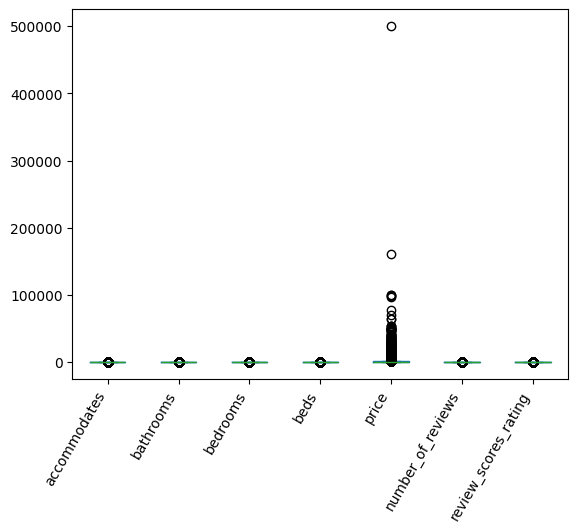

In [278]:
# Numeric cols boxplot
df_main[num_cols].plot.box()

plt.xticks(rotation=60, ha='right')
plt.show()

###3.4.3. Identifying Outliers

In [286]:
# Identifying
outliers_cols = [] # Flag columns list

for col in num_cols: # For each numeric column
  Q1 = df_main[col].quantile(0.25) # Get the Quartile 1
  Q3 = df_main[col].quantile(0.75) # Get the Quartile 3

  IQR = Q3 - Q1 # Get Interquartile Range

  LI = Q1 - 1.5*IQR # Get the lower limit
  LS = Q3 + 1.5*IQR # Get the upper limit

  df_main['outliers_' + col] = ((df_main[col] < LI) | (df_main[col] > LS))  # Create the outlier flag column (true for outlier)
  outliers_cols.append('outliers_' + col) # Append the outlier flag column to the list

In [287]:
# Checking data frame size after remove outliers (check the first row: 27741)
df_main[outliers_cols].value_counts() # Check the number of rows without outlier values (rows where all values are False)

outliers_accommodates  outliers_bathrooms  outliers_bedrooms  outliers_beds  outliers_price  outliers_number_of_reviews  outliers_review_scores_rating
False                  False               False              False          False           False                       False                            27741
                                                                                             True                        False                             4489
                                                                                             False                       True                              2409
                                                                             True            False                       False                             2076
True                   True                True               True           True            False                       False                              234
                                                                                                                                                          ...  
                       False               True               False          True            True                        False                                1
                       True                True               False          True            True                        False                                1
                                                                             False           True                        True                                 1
                                                              True           False           True                        True                                 1
                                                                             True            True                        True                                 1
Name: count, Length: 86, dtype: int64

###3.4.4. Removing Outliers

In [288]:
# Removing
for col in outliers_cols: # For each outliers flag column
  df_main = df_main[df_main[col] == False] # Filter not outliers rows and update main data frame
  df_main = df_main.drop(columns=col) # Remove outlier flag column

In [290]:
# Checking (must be 27741)
df_main.shape

(27741, 10)

#5. Transformando Dados Categóricos

##5.1.Análise

In [ ]:
#Quantidade de dados distintos em cada coluna categórica
df_main[cat_cols].nunique()

,0
neighbourhood_cleansed,145
room_type,4


`neighbourhood_cleansed`: Com 145 valores distintos, não é válido utilizar *One-Hot Encoding*, mas também não pode ser atribuído um valor numérico por *Label Encoding*, pois irá gerar interpretação ordinal entre os dados, o que não faz sentido quando trabalhamos com cidades. Pode ser possível avaliar as cidades e numerá-las conforme sua classificação, porém isto não faz parte da base de dados.

Sendo assim, há duas opções:

1.   Descartar esta coluna da análise;
2.   Realizar o *Label Encoding*, ciente de que os valores não indicam relação ordinal entre as cidades;

Vou realizar o *Label Encoding* apenas para a realização do desafio, com o objetivo de aplicar os conhecimentos do módulo.

`room_type`: Permite transformação por *one-hot encoding*.

##5.2.Label Encoding (`neighbourhood_cleansed`)

In [ ]:
#Coluna numérica com os códigos de cada cidade
df_main['neighbourhood_cleansed_number'] = df_main['neighbourhood_cleansed'].astype('category').cat.codes

In [ ]:
#Coluna numérica adicionada à lista
num_cols.append('neighbourhood_cleansed_number')

In [ ]:
#Exibe as colunas numéricas
df_main[num_cols]

,accommodates,bathrooms,bedrooms,beds,price,number_of_reviews,review_scores_rating,neighbourhood_cleansed_number
0,4,1,2,2,236.0,6,4.830000,136
2,2,1,1,2,1146.0,32,5.000000,31
4,1,1,1,1,61.0,5,5.000000,113
8,3,1,1,2,225.0,48,4.920000,113
19,3,2,1,1,377.0,6,4.830000,13
...,...,...,...,...,...,...,...,...
39494,4,2,1,2,957.0,0,4.812309,31
39495,8,1,1,1,288.0,0,4.812309,62
39496,6,1,1,4,672.0,0,4.812309,31
39497,6,1,2,1,1083.0,0,4.812309,58


##5.3.One-Hot Encoding (`room_type`)

In [ ]:
#Sinalizando room_type
df_main_dummies = pd.get_dummies(df_main['room_type'], dtype=int, prefix='room_type')

In [ ]:
df_main_dummies

,room_type_Entire home/apt,room_type_Hotel room,room_type_Private room,room_type_Shared room
0,1,0,0,0
2,0,0,1,0
4,0,0,1,0
8,1,0,0,0
19,0,0,1,0
...,...,...,...,...
39494,1,0,0,0
39495,1,0,0,0
39496,1,0,0,0
39497,1,0,0,0


In [ ]:
#Marcando 'dummies' como colunas numéricas
for col in df_main_dummies.columns: #Para cada coluna em df_main_dummies.columns
  num_cols.append(col) #Adiciona à lista de colunas numéricas

In [ ]:
#Concatenando tabelas One-Hot e removendo a coluna 'room_type'
df_main = pd.concat([df_main.drop(columns='room_type', axis=1), df_main_dummies], axis=1)

In [ ]:
#Atualizando 'df_main'
df_main = pd.concat([df_main['id'], df_main[num_cols]], axis=1)

In [ ]:
df_main

,id,accommodates,bathrooms,bedrooms,beds,price,number_of_reviews,review_scores_rating,neighbourhood_cleansed_number,room_type_Entire home/apt,room_type_Hotel room,room_type_Private room,room_type_Shared room
0,271975,4,1,2,2,236.0,6,4.830000,136,1,0,0,0
2,272631,2,1,1,2,1146.0,32,5.000000,31,0,0,1,0
4,273363,1,1,1,1,61.0,5,5.000000,113,0,0,1,0
8,274116,3,1,1,2,225.0,48,4.920000,113,1,0,0,0
19,280625,3,2,1,1,377.0,6,4.830000,13,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
39494,1319593870376466401,4,2,1,2,957.0,0,4.812309,31,1,0,0,0
39495,1319611826461021550,8,1,1,1,288.0,0,4.812309,62,1,0,0,0
39496,1319620401959854025,6,1,1,4,672.0,0,4.812309,31,1,0,0,0
39497,1319650312466603776,6,1,2,1,1083.0,0,4.812309,58,1,0,0,0


##5.4.Normalização (MinMax)

In [ ]:
#Normalização
for col in num_cols: #Para cada coluna numérica
  col_min = df_main[col].min() #Determina o menor valor
  col_max = df_main[col].max() #Determina o maior valor
  delta = col_max - col_min #Determina a diferença do maior para o menor

  df_main[col] = df_main[col].apply(lambda x: (x - col_min) / delta) #Normaliza cada valor da coluna

In [ ]:
#Conferência da normalização
df_main

,id,accommodates,bathrooms,bedrooms,beds,price,number_of_reviews,review_scores_rating,neighbourhood_cleansed_number,room_type_Entire home/apt,room_type_Hotel room,room_type_Private room,room_type_Shared room
0,271975,0.375,0.333333,0.666667,0.333333,0.090991,0.125000,0.595238,0.944444,1.0,0.0,0.0,0.0
2,272631,0.125,0.333333,0.333333,0.333333,0.498879,0.666667,1.000000,0.215278,0.0,0.0,1.0,0.0
4,273363,0.000,0.333333,0.333333,0.166667,0.012550,0.104167,1.000000,0.784722,0.0,0.0,1.0,0.0
8,274116,0.250,0.333333,0.333333,0.333333,0.086060,1.000000,0.809524,0.784722,1.0,0.0,0.0,0.0
19,280625,0.250,0.666667,0.333333,0.166667,0.154191,0.125000,0.595238,0.090278,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
39494,1319593870376466401,0.375,0.666667,0.333333,0.333333,0.414164,0.000000,0.553118,0.215278,1.0,0.0,0.0,0.0
39495,1319611826461021550,0.875,0.333333,0.333333,0.166667,0.114299,0.000000,0.553118,0.430556,1.0,0.0,0.0,0.0
39496,1319620401959854025,0.625,0.333333,0.333333,0.666667,0.286419,0.000000,0.553118,0.215278,1.0,0.0,0.0,0.0
39497,1319650312466603776,0.625,0.333333,0.666667,0.166667,0.470641,0.000000,0.553118,0.402778,1.0,0.0,0.0,0.0


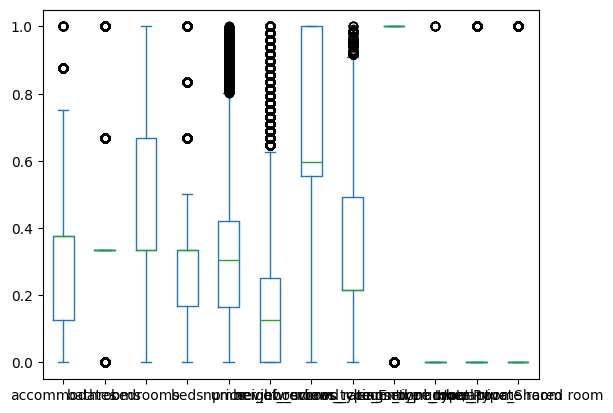

In [ ]:
#Boxplot normalizado
df_main[num_cols].plot(kind='box');

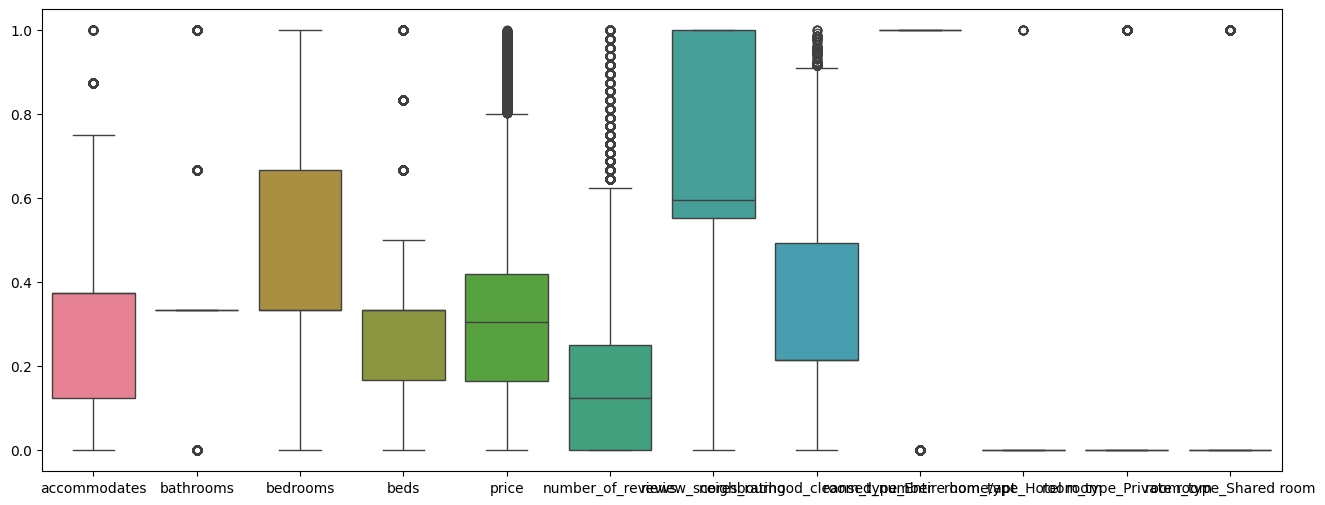

In [ ]:
#Boxplot normalizado
plt.figure(figsize=(16,6))
ax = sns.boxplot(data= df_main[num_cols])

#6. Conferindo Resultado Final

In [ ]:
#Verificação  das linhas iniciais
df_main.head()

,id,accommodates,bathrooms,bedrooms,beds,price,number_of_reviews,review_scores_rating,neighbourhood_cleansed_number,room_type_Entire home/apt,room_type_Hotel room,room_type_Private room,room_type_Shared room
0,271975,0.375,0.333333,0.666667,0.333333,0.090991,0.125000,0.595238,0.944444,1.0,0.0,0.0,0.0
2,272631,0.125,0.333333,0.333333,0.333333,0.498879,0.666667,1.000000,0.215278,0.0,0.0,1.0,0.0
4,273363,0.000,0.333333,0.333333,0.166667,0.012550,0.104167,1.000000,0.784722,0.0,0.0,1.0,0.0
8,274116,0.250,0.333333,0.333333,0.333333,0.086060,1.000000,0.809524,0.784722,1.0,0.0,0.0,0.0
19,280625,0.250,0.666667,0.333333,0.166667,0.154191,0.125000,0.595238,0.090278,0.0,0.0,1.0,0.0


In [ ]:
#Tipos de dados
df_main.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27741 entries, 0 to 39498
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   id                             27741 non-null  int64  
 1   accommodates                   27741 non-null  float64
 2   bathrooms                      27741 non-null  float64
 3   bedrooms                       27741 non-null  float64
 4   beds                           27741 non-null  float64
 5   price                          27741 non-null  float64
 6   number_of_reviews              27741 non-null  float64
 7   review_scores_rating           27741 non-null  float64
 8   neighbourhood_cleansed_number  27741 non-null  float64
 9   room_type_Entire home/apt      27741 non-null  float64
 10  room_type_Hotel room           27741 non-null  float64
 11  room_type_Private room         27741 non-null  float64
 12  room_type_Shared room          27741 non-null  floa

In [ ]:
#Reset de 'index'
df_main.reset_index(inplace=True, drop=True)

In [ ]:
#Conferência dos dados estatísticos (normalizados)
df_main.describe()

,id,accommodates,bathrooms,bedrooms,beds,price,number_of_reviews,review_scores_rating,neighbourhood_cleansed_number,room_type_Entire home/apt,room_type_Hotel room,room_type_Private room,room_type_Shared room
count,2.774100e+04,27741.000000,27741.000000,27741.000000,27741.000000,27741.000000,27741.000000,27741.000000,27741.000000,27741.000000,27741.000000,27741.000000,27741.000000
mean,7.689097e+17,0.314940,0.419752,0.456412,0.334042,0.319637,0.184383,0.707167,0.343474,0.767564,0.000577,0.225226,0.006633
std,5.023266e+17,0.193269,0.180183,0.222691,0.184727,0.205879,0.239557,0.240406,0.240190,0.422393,0.024009,0.417739,0.081173
min,6.166100e+04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.306519e+07,0.125000,0.333333,0.333333,0.166667,0.164500,0.000000,0.553118,0.215278,1.000000,0.000000,0.000000,0.000000
50%,9.901469e+17,0.375000,0.333333,0.333333,0.333333,0.305244,0.125000,0.595238,0.215278,1.000000,0.000000,0.000000,0.000000
75%,1.192295e+18,0.375000,0.333333,0.666667,0.333333,0.419543,0.250000,1.000000,0.493056,1.000000,0.000000,0.000000,0.000000
max,1.320520e+18,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
#Visualização das colunas
df_main.columns

Index(['id', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'price',
       'number_of_reviews', 'review_scores_rating',
       'neighbourhood_cleansed_number', 'room_type_Entire home/apt',
       'room_type_Hotel room', 'room_type_Private room',
       'room_type_Shared room'],
      dtype='object')

#7. Pipeline

In [ ]:
def read_data(filename1, filename2):
  path = "https://raw.githubusercontent.com/RafaSFernandes/data-cleaning-and-wrangling-airbnb/refs/heads/main/data/"
  df_main = pd.merge(pd.read_csv(path + filename1), pd.read_csv(path + filename2), how='left', on='id')
  return df_main

def basic_info(df):
  print("Dimensões (Linhas, Colunas)", df.shape)
  missing_values = df.isnull().sum()
  missing_values = missing_values[missing_values > 0]
  duplicated_values = df.duplicated()
  duplicated_values = duplicated_values[duplicated_values > 0]
  if missing_values.empty:
    print('Base sem dados faltantes.')
  else:
    print('Base com dados faltantes.')
    print(f"Colunas com dados faltantes\n{missing_values.index}")

  if duplicated_values.empty:
    print('Base sem dados duplicados.')
  else:
    print('Base com dados duplicados.')
    print(f"Linhas com dados duplicados\n{duplicated_values.index}")
  return df.dtypes

def null_hand(df):
  num_cols = df.select_dtypes(include='number').drop('id', axis=1).columns
  df = df.fillna(df[num_cols].median(), inplace=True)
  return df

def duplicated_hand(df):
  df = df.drop_duplicates()
  return df

def cols_types(df):
  int_cols = ['accommodates', 'bathrooms', 'bedrooms', 'beds', 'number_of_reviews']
  df[int_cols] = df[int_cols].astype(int)
  return df[int_cols]

def outliers(df):
  num_cols = df.select_dtypes(include='number').drop('id', axis=1).columns
  outliers_cols = [] #Lista de colunas indicadoras de outliers

  for col in num_cols: #Para cada coluna numérica
    Q1 = df[col].quantile(0.25) #Calcula o quartil 1
    Q3 = df[col].quantile(0.75) #Calcula o quartil 3
    IQR = Q3 - Q1 #Calcula o IQR
    LI = Q1 - 1.5*IQR #Determina o limite inferior
    LS = Q3 + 1.5*IQR #Determina o limite superior

    df['outliers_' + col] = ((df[col] < LI) | (df[col] > LS))
    outliers_cols.append('outliers_' + col)

  for col in outliers_cols:
    df = df[df[col] == False]
    df = df.drop(columns=col)

  return df

def label_encode_col(df, column_name):
  df[column_name + '_number'] = df[column_name].astype('category').cat.codes
  return df

def onehot_encode_col(df, column_name):
  df_dummies = pd.get_dummies(df[column_name], dtype=int, prefix='room_type')
  df = pd.concat([df.drop(columns=column_name, axis=1), df_dummies], axis=1)
  return df

def transform_cat_cols(df):
  label_encode_cols = ['neighbourhood_cleansed']
  onehot_encode_cols = ['room_type']

  for col in label_encode_cols:
    df = label_encode_col(df, col).drop(col, axis=1)

  for col in onehot_encode_cols:
    df = onehot_encode_col(df, col)
  return df

def normalize_column(df, column_name):
  df[column_name] = (df[column_name] - df[column_name].min()) / (df[column_name].max() - df[column_name].min())
  return df

def normalize(df):
  columns = df.select_dtypes(include='number').drop('id', axis=1).columns
  for col in columns:
    df = normalize_column(df, col)
  return df

def process(filename1, filename2):
  df = read_data(filename1, filename2)
  basic_info(df)
  missing_values = df.isnull().sum()
  missing_values = missing_values[missing_values > 0]
  duplicated_values = df.duplicated()
  duplicated_values = duplicated_values[duplicated_values > 0]
  if missing_values.any:
    null_hand(df)
  if duplicated_values.any:
    duplicated_hand(df)
  cols_types(df)
  df = outliers(df)
  df = transform_cat_cols(df)
  df = normalize(df)

  return df

In [ ]:
pipe_test = process('listings_cleaned.csv', 'reviews.csv')

Dimensões (Linhas, Colunas) (39499, 10)
Base com dados faltantes.
Colunas com dados faltantes
Index(['bathrooms', 'bedrooms', 'beds', 'price', 'number_of_reviews',
       'review_scores_rating'],
      dtype='object')
Base sem dados duplicados.


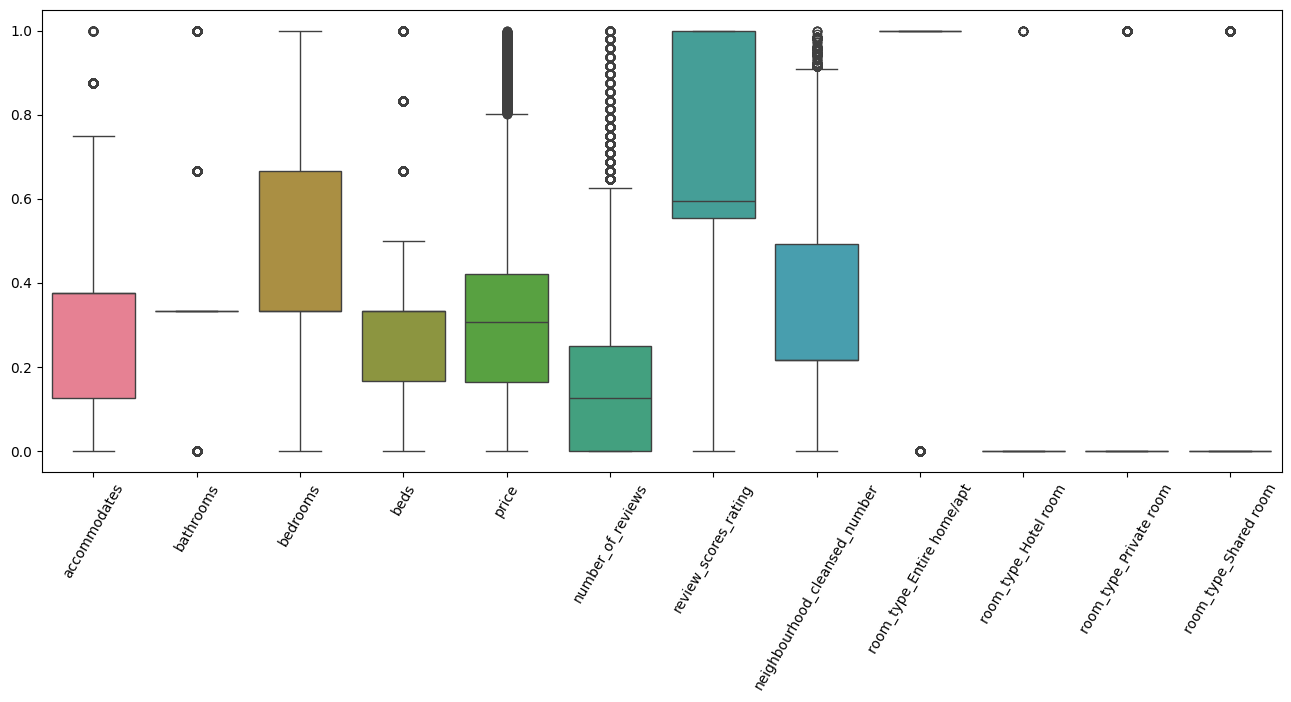

In [ ]:
plt.figure(figsize=(16,6))
ax = sns.boxplot(data= pipe_test.drop('id', axis=1))

plt.xticks(rotation=60)
plt.show()